# <b>[공모전] RNN 시계열 날씨 예측

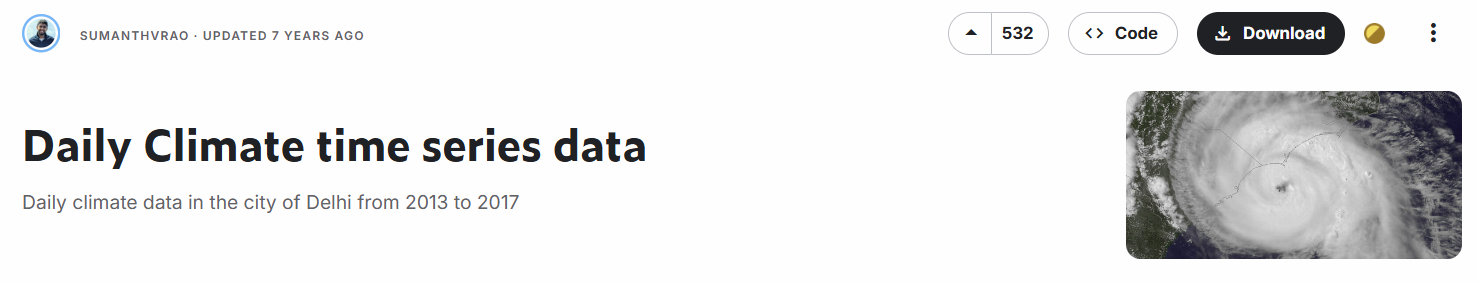
* https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, GRU, Bidirectional
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras.initializers import GlorotNormal    #Xavier

import math
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler


#----------------------------------------------------------------------------------  랜덤시드 고정 
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>Data Load

In [2]:
test = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\Daily Climate time\DailyDelhiClimateTest.csv")
dataset= pd.read_csv(r"C:\IT\workspace_ptyhon\dl\Daily Climate time\DailyDelhiClimateTrain.csv")

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


# <b>train_test_split

train(1402일) - train(80%), val(20%) <br>
test(60일)

In [4]:
test = dataset[-30:]
len(dataset), len(test)

(1462, 30)

In [5]:
train, val = train_test_split(dataset[:-60], test_size = 0.2, shuffle = False)
len(train), len(val)

(1121, 281)

# <b>EDA

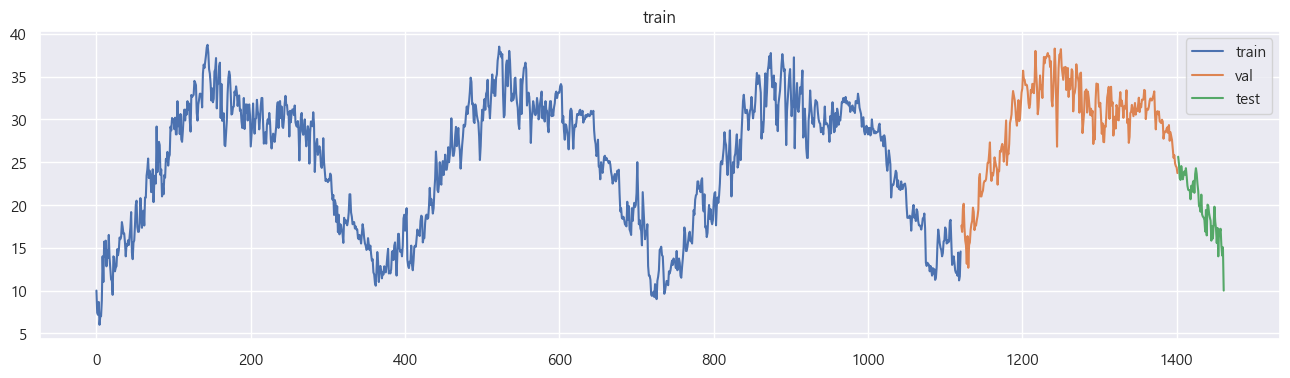

In [6]:
dataset['meantemp'][:len(train)].plot(figsize=(16,4),legend=True) # 평균온도컬럼의 처음부터 train길이까지
dataset["meantemp"][len(train) : len(train)+len(val)].plot(figsize=(16,4),legend=True) # train ~ train+val까지
dataset["meantemp"][len(train)+len(val) : ].plot(figsize=(16,4),legend=True) # train+val ~ 끝까지

plt.legend(['train','val','test']) # 범례설정
plt.title('train')
plt.show()

```python
[:len(train)]
[len(train):len(train)+len(val)]
[len(train)+len(val):]
시계열 train/val/test자르는 기본패턴

# <b>전처리 & 가공

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [13]:
print(dataset.describe())

                      date     meantemp     humidity   wind_speed  \
count                 1462  1462.000000  1462.000000  1462.000000   
mean   2015-01-01 12:00:00    25.495521    60.771702     6.802209   
min    2013-01-01 00:00:00     6.000000    13.428571     0.000000   
25%    2014-01-01 06:00:00    18.857143    50.375000     3.475000   
50%    2015-01-01 12:00:00    27.714286    62.625000     6.221667   
75%    2016-01-01 18:00:00    31.305804    72.218750     9.238235   
max    2017-01-01 00:00:00    38.714286   100.000000    42.220000   
std                    NaN     7.348103    16.769652     4.561602   

       meanpressure        month          day    dayofyear     month_sin  \
count   1462.000000  1462.000000  1462.000000  1462.000000  1.462000e+03   
mean    1011.104548     6.519152    15.719562   183.000684 -4.439385e-03   
min       -3.041667     1.000000     1.000000     1.000000 -1.000000e+00   
25%     1001.580357     4.000000     8.000000    92.000000 -8.660254e-01  

In [14]:
print(dataset[['meantemp','humidity','wind_speed','meanpressure']].describe())

          meantemp     humidity   wind_speed  meanpressure
count  1462.000000  1462.000000  1462.000000   1462.000000
mean     25.495521    60.771702     6.802209   1011.104548
std       7.348103    16.769652     4.561602    180.231668
min       6.000000    13.428571     0.000000     -3.041667
25%      18.857143    50.375000     3.475000   1001.580357
50%      27.714286    62.625000     6.221667   1008.563492
75%      31.305804    72.218750     9.238235   1014.944901
max      38.714286   100.000000    42.220000   7679.333333


## <b>파생피처

* <b>원리이해 - 파이썬 기본 자료구조

<pre>
<font color=red size=3><b>
리스트        : [1 , 2 , 3]
np.array(..)  : [1   2  3 ]
튜플          : (1  ,2  ,3)
셋            : {1  ,2  ,3}   --- 중복제거(duplicate, cascade)
딕셔너리      : {"a":1, "b":[1,2]}

In [10]:
# date 컬럼을 datetime으로 변환
dataset['date'] = pd.to_datetime(dataset['date'])

# 날짜 관련 파생 피처
dataset['month'] = dataset['date'].dt.month
dataset['day']   = dataset['date'].dt.day
dataset['dayofyear'] = dataset['date'].dt.dayofyear

# 계절성을 담은 sin/cos 피처 (월 기반) 12월->1월로 끊기는 문제 해결
dataset['month_sin'] = np.sin(2 * np.pi * dataset['month'] / 12)
dataset['month_cos'] = np.cos(2 * np.pi * dataset['month'] / 12)

# 사용할 피처 컬럼 정의
feature_cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure',
                'month_sin', 'month_cos']
target_col   = 'meantemp'

dataset[feature_cols].head()

,meantemp,humidity,wind_speed,meanpressure,month_sin,month_cos
0,10.000000,84.500000,0.000000,1015.666667,0.5,0.866025
1,7.400000,92.000000,2.980000,1017.800000,0.5,0.866025
2,7.166667,87.000000,4.633333,1018.666667,0.5,0.866025
3,8.666667,71.333333,1.233333,1017.166667,0.5,0.866025
4,6.000000,86.833333,3.700000,1016.500000,0.5,0.866025


## <b>스케일링
* LSTM은 0~1
* 스케일러를 val에 fit하면 데이터 누수

In [11]:
# train/val/test 재분리 (feature_cols 기준)
train_df, val_df = train_test_split(dataset[:-60], test_size=0.2, shuffle=False)
test_df = dataset[-60:]

# MinMaxScaler는 반드시 train 기준으로만 fit!
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols])
val_scaled   = scaler.transform(val_df[feature_cols])
test_scaled  = scaler.transform(test_df[feature_cols])

# 타겟(meantemp)이 몇 번째 컬럼인지 기억해두기
target_idx = feature_cols.index(target_col)  # 0
print(f"train: {train_scaled.shape}, val: {val_scaled.shape}, test: {test_scaled.shape}")

train: (1121, 6), val: (281, 6), test: (60, 6)


## <b>윈도우 슬라이딩

In [12]:
window_size = 7  # 7일치 보고 다음날 예측

def make_windows(data, window_size, target_idx):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])        # 모든 피처
        y.append(data[i, target_idx])             # 타겟만
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_scaled, window_size, target_idx)
X_val,   y_val   = make_windows(val_scaled,   window_size, target_idx)
X_test,  y_test  = make_windows(test_scaled,  window_size, target_idx)

print(f"X_train: {X_train.shape}")  # (samples, 7, 6)
print(f"y_train: {y_train.shape}")  # (samples,)

X_train: (1114, 7, 6)
y_train: (1114,)


## <font color=red><b>input_shape : 3D
* samples : 데이터 갯수
* timestep : window_size
* features : 변수갯수 == df['cnt']

# <b>모델 & 평가

In [20]:
n_features = X_train.shape[2]  # 피처 수 (6개)

model = Sequential([
    # 1층: return_sequences=True ← 이게 핵심 변경점!
    LSTM(64, input_shape=(window_size, n_features), return_sequences=True),
    Dropout(0.2),
    
    # 2층: 마지막이니까 return_sequences=False (기본값)
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 7, 64)               │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,681 (123.75 KB)

 Trainable params: 31,681 (123.75 KB)

 Non-trainable params: 0 (0.00 B)

학습

In [21]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[es]
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1163 - mae: 0.2687 - val_loss: 0.0522 - val_mae: 0.2029
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0154 - mae: 0.0978 - val_loss: 0.0183 - val_mae: 0.0949
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0091 - mae: 0.0758 - val_loss: 0.0175 - val_mae: 0.0903
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0088 - mae: 0.0744 - val_loss: 0.0174 - val_mae: 0.0897
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0084 - mae: 0.0723 - val_loss: 0.0162 - val_mae: 0.0844
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0075 - mae: 0.0674 - val_loss: 0.0147 - val_mae: 0.0787
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0075 - mae: 0.0678 - val_loss: 0.0145 - val_mae: 0.0786
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0067 - mae: 0.0636 - val_loss: 0.0159 - val_mae: 0.0867
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.00

학습곡선확인

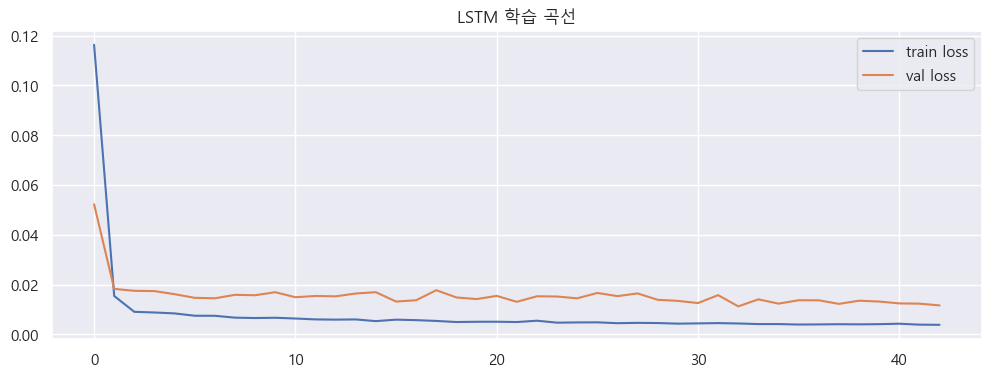

In [22]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'],     label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('LSTM 학습 곡선')
plt.show()

예측 & 역스케일링<br>
스케일링한거 다시 원래 온도로 되돌리기

In [23]:
def inverse_target(scaled_vals, scaler, target_idx, n_features): # 숫자->온도로 되돌리기
    dummy = np.zeros((len(scaled_vals), n_features))
    dummy[:, target_idx] = scaled_vals
    return scaler.inverse_transform(dummy)[:, target_idx]

# 예측
pred_scaled  = model.predict(X_test).flatten()

# 역스케일링
pred_real   = inverse_target(pred_scaled, scaler, target_idx, len(feature_cols))
y_test_real = inverse_target(y_test,      scaler, target_idx, len(feature_cols))

# RMSE
rmse = math.sqrt(mean_squared_error(y_test_real, pred_real))
print(f"RMSE: {rmse:.2f} °C")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
RMSE: 2.32 °C


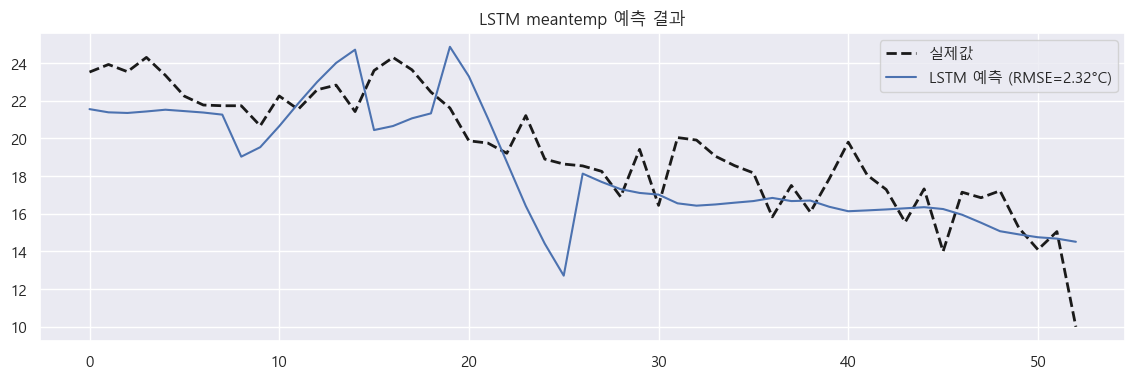

In [24]:
plt.figure(figsize=(14, 4))
plt.plot(y_test_real, 'k--', label='실제값', linewidth=2)
plt.plot(pred_real,   label=f'LSTM 예측 (RMSE={rmse:.2f}°C)')
plt.legend()
plt.title('LSTM meantemp 예측 결과')
plt.show()

In [25]:
print(history.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


In [26]:
# 수치로 확인
print(f"train loss: {min(history.history['loss']):.4f}")
print(f"val loss:   {min(history.history['val_loss']):.4f}")
print(f"train MAE:  {min(history.history['mae']):.4f}")
print(f"val MAE:    {min(history.history['val_mae']):.4f}")

train loss: 0.0039
val loss:   0.0113
train MAE:  0.0487
val MAE:    0.0786


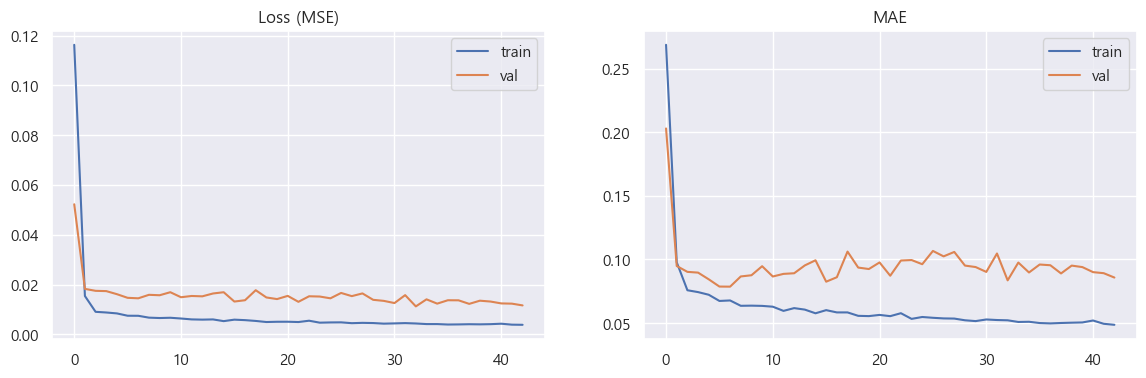

In [27]:
# 그래프로 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss (MSE)')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='train')
axes[1].plot(history.history['val_mae'], label='val')
axes[1].set_title('MAE')
axes[1].legend()

plt.show()